# Optimal Transport Alignment with ESM-1b

## Setup

In [ ]:
import sys
from typing import Optional, TextIO

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
from utils import aln_to_matches, convolve2d

from train import build_aligner, build_transform_head, build_wrapper_model


# os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
torch.set_grad_enabled(False)
# sys.path.insert(0, str(pathlib.Path().absolute()))

## Experiments 

In [2]:
def print_alignment(
    seq1: str,
    seq2: str,
    path: str,
    max_width: int = 80,
    outfile: TextIO = sys.stdout,
    seq1_label: Optional[str] = None,
    seq2_label: Optional[str] = None,
):
    """
    seq1: the first input sequence (length M)
    seq2: the second input sequence (length N)
    path: alignment moves string, each character is 'M', 'I', or 'D'
    max_width: maximum number of alignment columns to print per line (default 80)
    outfile: file-like object to write output to (default sys.stdout)
    seq1_label: custom label for the first sequence (default 'Seq1')
    seq2_label: custom label for the second sequence (default 'Seq2')
    """
    # Assign default labels if None
    label1 = seq1_label if seq1_label is not None else "Seq1"
    label2 = seq2_label if seq2_label is not None else "Seq2"

    # Initialize sequence indices and buffers
    i = j = 0  # indices in original sequences
    aligned1 = []  # Holds the aligned chars for seq1 (including gaps)
    aligned2 = []  # Holds the aligned chars for seq2 (including gaps)
    match_line = []  # Holds '|' for matches or ' ' otherwise
    pos1: list[Optional[int]] = []  # Original residue numbers for aligned1
    pos2: list[Optional[int]] = []  # Original residue numbers for aligned2
    match_count = aligned_count = gap_count = 0

    # Build aligned sequences, match/mismatch line, and position arrays
    for move in path:
        if move == "M":
            c1, c2 = seq1[i], seq2[j]
            aligned1.append(c1)
            aligned2.append(c2)
            pos1.append(i + 1)  # 1-based index
            pos2.append(j + 1)
            if c1 == c2:
                match_line.append(":")
                match_count += 1
            else:
                match_line.append(".")
            aligned_count += 1
            i += 1
            j += 1
        elif move == "I":
            aligned1.append("-")
            aligned2.append(seq2[j])
            pos1.append(None)
            pos2.append(j + 1)
            match_line.append(" ")
            gap_count += 1
            j += 1
        elif move == "D":
            aligned1.append(seq1[i])
            aligned2.append("-")
            pos1.append(i + 1)
            pos2.append(None)
            match_line.append(" ")
            gap_count += 1
            i += 1
        else:
            raise ValueError(f"Invalid move '{move}'; expected 'M', 'I', or 'D'.")

    alignment_length = len(path)
    identity = (match_count / aligned_count * 100) if aligned_count > 0 else 0.0

    # Print the alignment in blocks with residue numbers
    for start in range(0, alignment_length, max_width):
        end = min(start + max_width, alignment_length)
        seg1 = "".join(aligned1[start:end])
        segm = "".join(match_line[start:end])
        seg2 = "".join(aligned2[start:end])
        # compute start/end residue numbers (skip gaps)
        block_pos1 = [p for p in pos1[start:end] if p is not None]
        block_pos2 = [p for p in pos2[start:end] if p is not None]
        start1 = block_pos1[0] if block_pos1 else None
        end1 = block_pos1[-1] if block_pos1 else None
        start2 = block_pos2[0] if block_pos2 else None
        end2 = block_pos2[-1] if block_pos2 else None

        # format number labels
        num1 = f"({start1}-{end1})" if start1 is not None else "(---)"
        num2 = f"({start2}-{end2})" if start2 is not None else "(---)"

        # print seq1 line with numbers
        print(f"{label1:12s} {num1:>10} : {seg1}", file=outfile)
        # print match/mismatch line
        print(f"{' ' * 24}: {segm}", file=outfile)
        # print seq2 line with numbers
        print(f"{label2:12s} {num2:>10} : {seg2}", file=outfile)
        print(file=outfile)

    # Print overall statistics
    print(f"Alignment length  : {alignment_length}", file=outfile)
    print(f"Aligned positions : {aligned_count}", file=outfile)
    print(f"Matches           : {match_count}", file=outfile)
    print(f"Gaps              : {gap_count}", file=outfile)
    print(f"Identity          : {identity:.2f}%", file=outfile)

    return aligned1, aligned2

In [3]:
with open("config.yaml") as f:
    cfg = yaml.safe_load(f)

cfg["device"] = "cpu"
cfg["max_seqlen"] = 1024
# cfg["model_checkpoint"] = "facebook/esm2_t33_650M_UR50D"

wrapper_model = build_wrapper_model(cfg)
transform = build_transform_head(cfg)
aligner = build_aligner(cfg)

wrapper_model.eval()
transform.eval()

transform.load_state_dict(torch.load("ckpt/latest.pth", weights_only=True))

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm1b_t33_650M_UR50S and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


<All keys matched successfully>

In [4]:
def align(score_matrix: np.ndarray, gap: float):
    """
    Perform a glocal alignment using a precomputed score matrix.
    seq1 of length M, seq2 of length N, with float score_matrix[M, N].
    End-gaps in seq2 are free (i.e., starting and trailing gaps in seq2 carry no penalty),
    but seq1 is globally aligned (gaps in seq1 are penalized).

    Args:
        score_matrix: numpy.ndarray of shape (M, N), match/mismatch scores.
        gap: float, penalty for any gap (insertion or deletion).

    Returns:
        ops: str of operations of length L in {'M', 'I', 'D'}:
            'M' = align seq1[i] to seq2[j],
            'D' = delete seq1[i] (gap in seq2),
            'I' = insert gap in seq1 (advance in seq2).
        best_score: float, optimal alignment score.
    """
    M, N = score_matrix.shape
    # DP score matrix and backtrack pointers
    dp = np.full((M + 1, N + 1), -np.inf, dtype=float)
    bt = np.empty((M + 1, N + 1), dtype="<U1")  # holds 'M','D','I'

    # initialization: global in seq1 (deletions penalized), glocal in seq2
    dp[0, 0] = 0.0
    for i in range(1, M + 1):
        dp[i, 0] = dp[i - 1, 0] + gap
        bt[i, 0] = "D"
    for j in range(1, N + 1):
        dp[0, j] = 0.0
        bt[0, j] = "I"

    # fill DP
    for i in range(1, M + 1):
        for j in range(1, N + 1):
            # match/mismatch from precomputed
            match_score = dp[i - 1, j - 1] + score_matrix[i - 1, j - 1]
            # deletion (gap in seq2)
            del_score = dp[i - 1, j] + gap
            # insertion (gap in seq1)
            ins_score = dp[i, j - 1] + gap
            # choose best
            best = match_score
            op = "M"
            if del_score > best:
                best, op = del_score, "D"
            if ins_score > best:
                best, op = ins_score, "I"
            dp[i, j] = best
            bt[i, j] = op

    # find optimal end position: full seq1 aligned, seq2 may end anywhere
    end_j = int(np.argmax(dp[M, :]))
    best_score = float(dp[M, end_j])

    # backtrack
    ops = []
    i, j = M, end_j
    while i > 0 or j > 0:
        if i > 0 and j > 0 and bt[i, j] == "M":
            ops.append("M")
            i, j = i - 1, j - 1
        elif i > 0 and bt[i, j] == "D":
            ops.append("D")
            i -= 1
        elif j > 0 and bt[i, j] == "I":
            ops.append("I")
            j -= 1
        else:
            # at top row, free end gaps in seq2
            if j > 0:
                ops.append("I")
                j -= 1
            else:
                break
    ops.reverse()
    return "".join(ops), best_score

Seq1             (1-80) : QMRLVESGGGCVRPGGSLRLSCAGSGFRFTGYGIHWVRQAPGKGLEWLAYISNDGSKKYHTDSVKGRFTVSRDNAKNTAY
                        : . .:.......:.::......:.:....  :...::..:..:..........  .. .. .. ...:...:...  :::.
Seq2             (1-70) : Y-VLTQPPSVSVAPGQTATITCGGNNIG--GKSVHWFQQKCGQAPLLIISDD--ND-RP-SG-IPERVSGSNSG--NTAT

Seq1           (81-123) : LQMNSLRVEETAVYFCAKDGYLSAARGYGMDVWGQGICVTVSP
                        : :..........:.:.:......:. .    .:.:.:...::. 
Seq2           (71-107) : LTISRVECGDEADYYCQVWDTTSD-Q----LVFGGGTMLTVL-

Alignment length  : 123
Aligned positions : 107
Matches           : 26
Gaps              : 16
Identity          : 24.30%


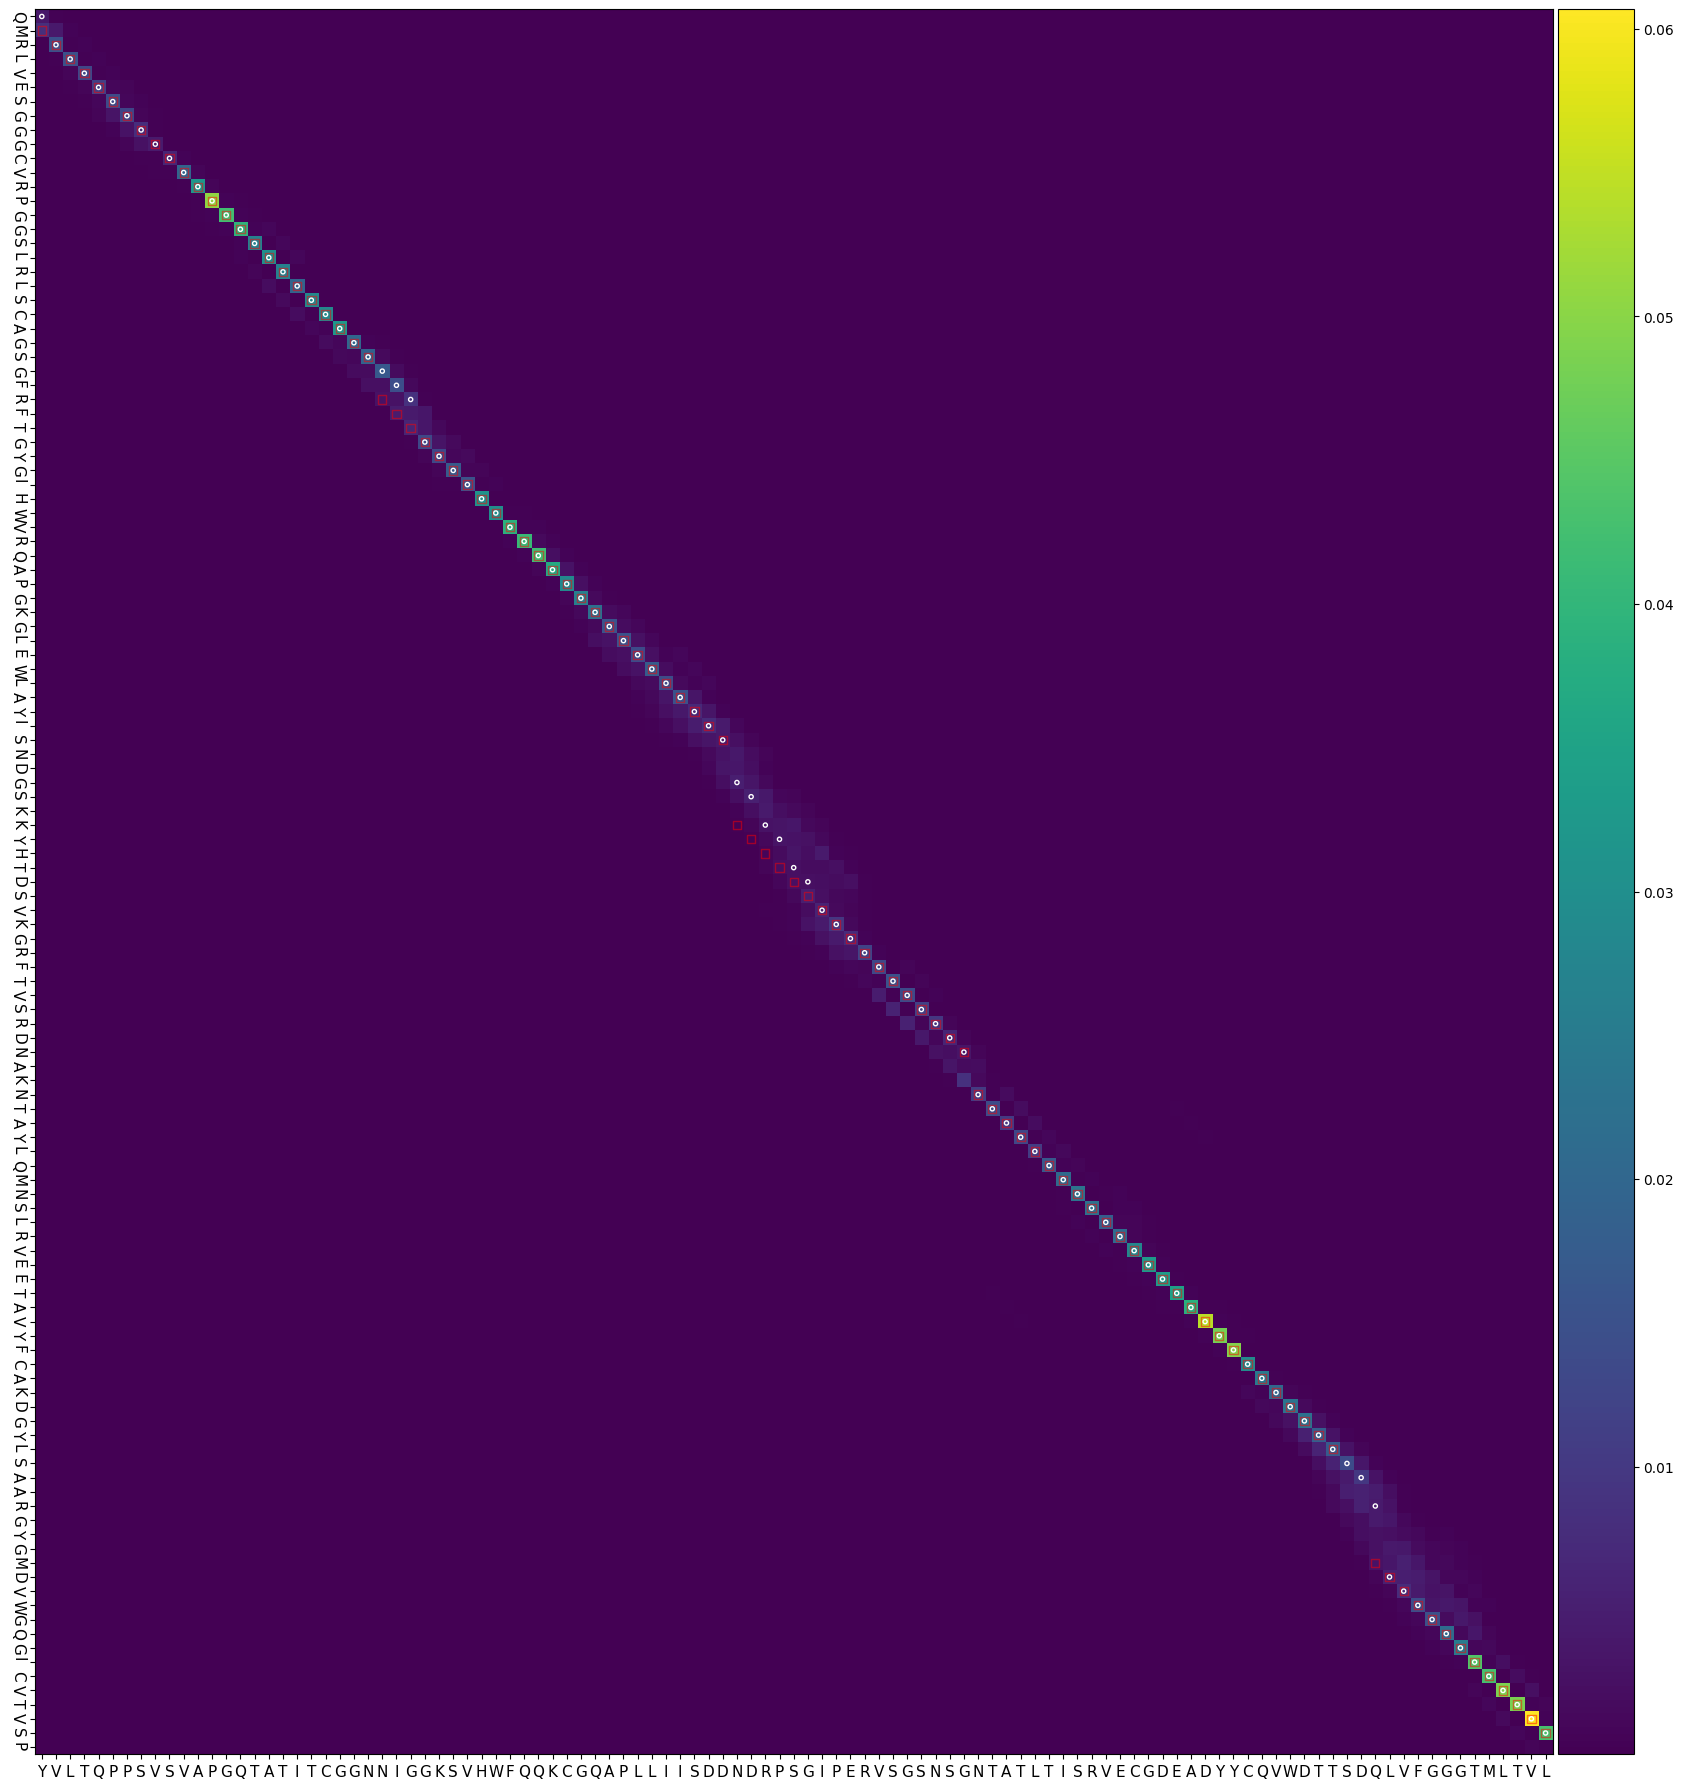

In [ ]:
tm_out = """
-YVLTQPPSVSVAPGQTATITCGGN--NIGGKSVHWFQQKCGQAPLLIISDD-----NDRPSGIPERVSGSNSG--NT
 ::::::.:::::::::::::::::  :::::::::::::::::::::::::     :::::::::::::::::  ::
QMRLVESGGGCVRPGGSLRLSCAGSGFRFTGYGIHWVRQAPGKGLEWLAYISNDGSKKYHTDSVKGRFTVSRDNAKNT

ATLTISRVECGDEADYYCQVWDTTSD-------QLVFGGGTMLTVL-
:::::::::::::::::::::...         .::::::::::::
AYLQMNSLRVEETAVYFCAKDGYL--SAARGYGMDVWGQGICVTVSP
"""  # 9iyy_L, 9iyy_H

lines = tm_out.strip().splitlines()
gt_aln2 = "".join(lines[0::4])
gt_aln1 = "".join(lines[2::4])

gt_matches = aln_to_matches(gt_aln1, gt_aln2)
# gt_matches.clear()

seq1 = gt_aln1.replace("-", "")
seq2 = gt_aln2.replace("-", "")

a, mask_a = wrapper_model(seq1)
b, mask_b = wrapper_model(seq2)
# full_mask = mask_a.unsqueeze(-3) & mask_b.unsqueeze(-2)

a = transform(a)
b = transform(b)

# res = aligner(a, b, mask_a, mask_b, 100, 0.05, 0.01, 0.01)
res = aligner(a, b, mask_a, mask_b, cfg["num_iter"], cfg["reg"], cfg["lambda1"], cfg["lambda2"])
mat = res["transport_plan"][0][mask_a.squeeze(0)][:, mask_b.squeeze(0)]
mat = mat.cpu().numpy()
mat /= mat.sum()

ker = np.eye(3)
img = convolve2d(mat, ker, padding_mode="same")

S = np.prod(mat.shape) * mat
path, _ = align(S, gap=-S.max())
aln1, aln2 = print_alignment(seq1, seq2, path)
matches = aln_to_matches(aln1, aln2)
# matches.clear()

# Figure
fig, ax = plt.subplots(1, 1, figsize=(24, 18))
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
im = ax.imshow(
    img,
    # np.log(img),
    # cmap=mpl.colormaps["terrain"],
    # clim=(0, 1),
    interpolation="none",
)
fig.colorbar(im, cax=cax)

ax.set_xticks(range(len(seq2)), labels=list(seq2), fontsize=11)
ax.set_yticks(range(len(seq1)), labels=list(seq1), fontsize=11, rotation=270)

if gt_matches:
    X = np.array(gt_matches)
    ax.scatter(
        X[:, 1],
        X[:, 0],
        facecolors="None",
        marker="s",
        edgecolor="r",
        alpha=0.5,
    )

if matches:
    X = np.array(matches)
    ax.scatter(
        X[:, 1],
        X[:, 0],
        facecolors="None",
        marker=".",
        edgecolor="w",
        alpha=1.0,
    )

fig.tight_layout()
fig.savefig("target.svg")
fig.show()

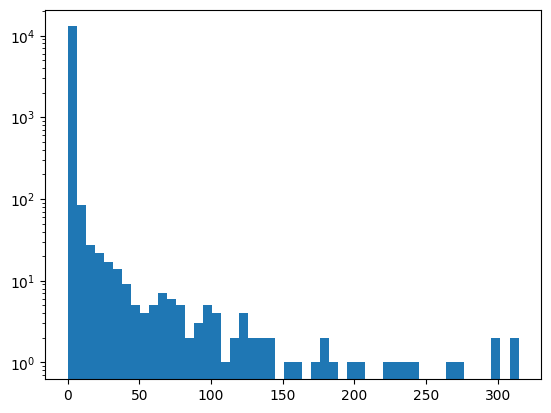

In [16]:
plt.hist(S.flatten(), bins=50)
plt.yscale("log")
plt.show()

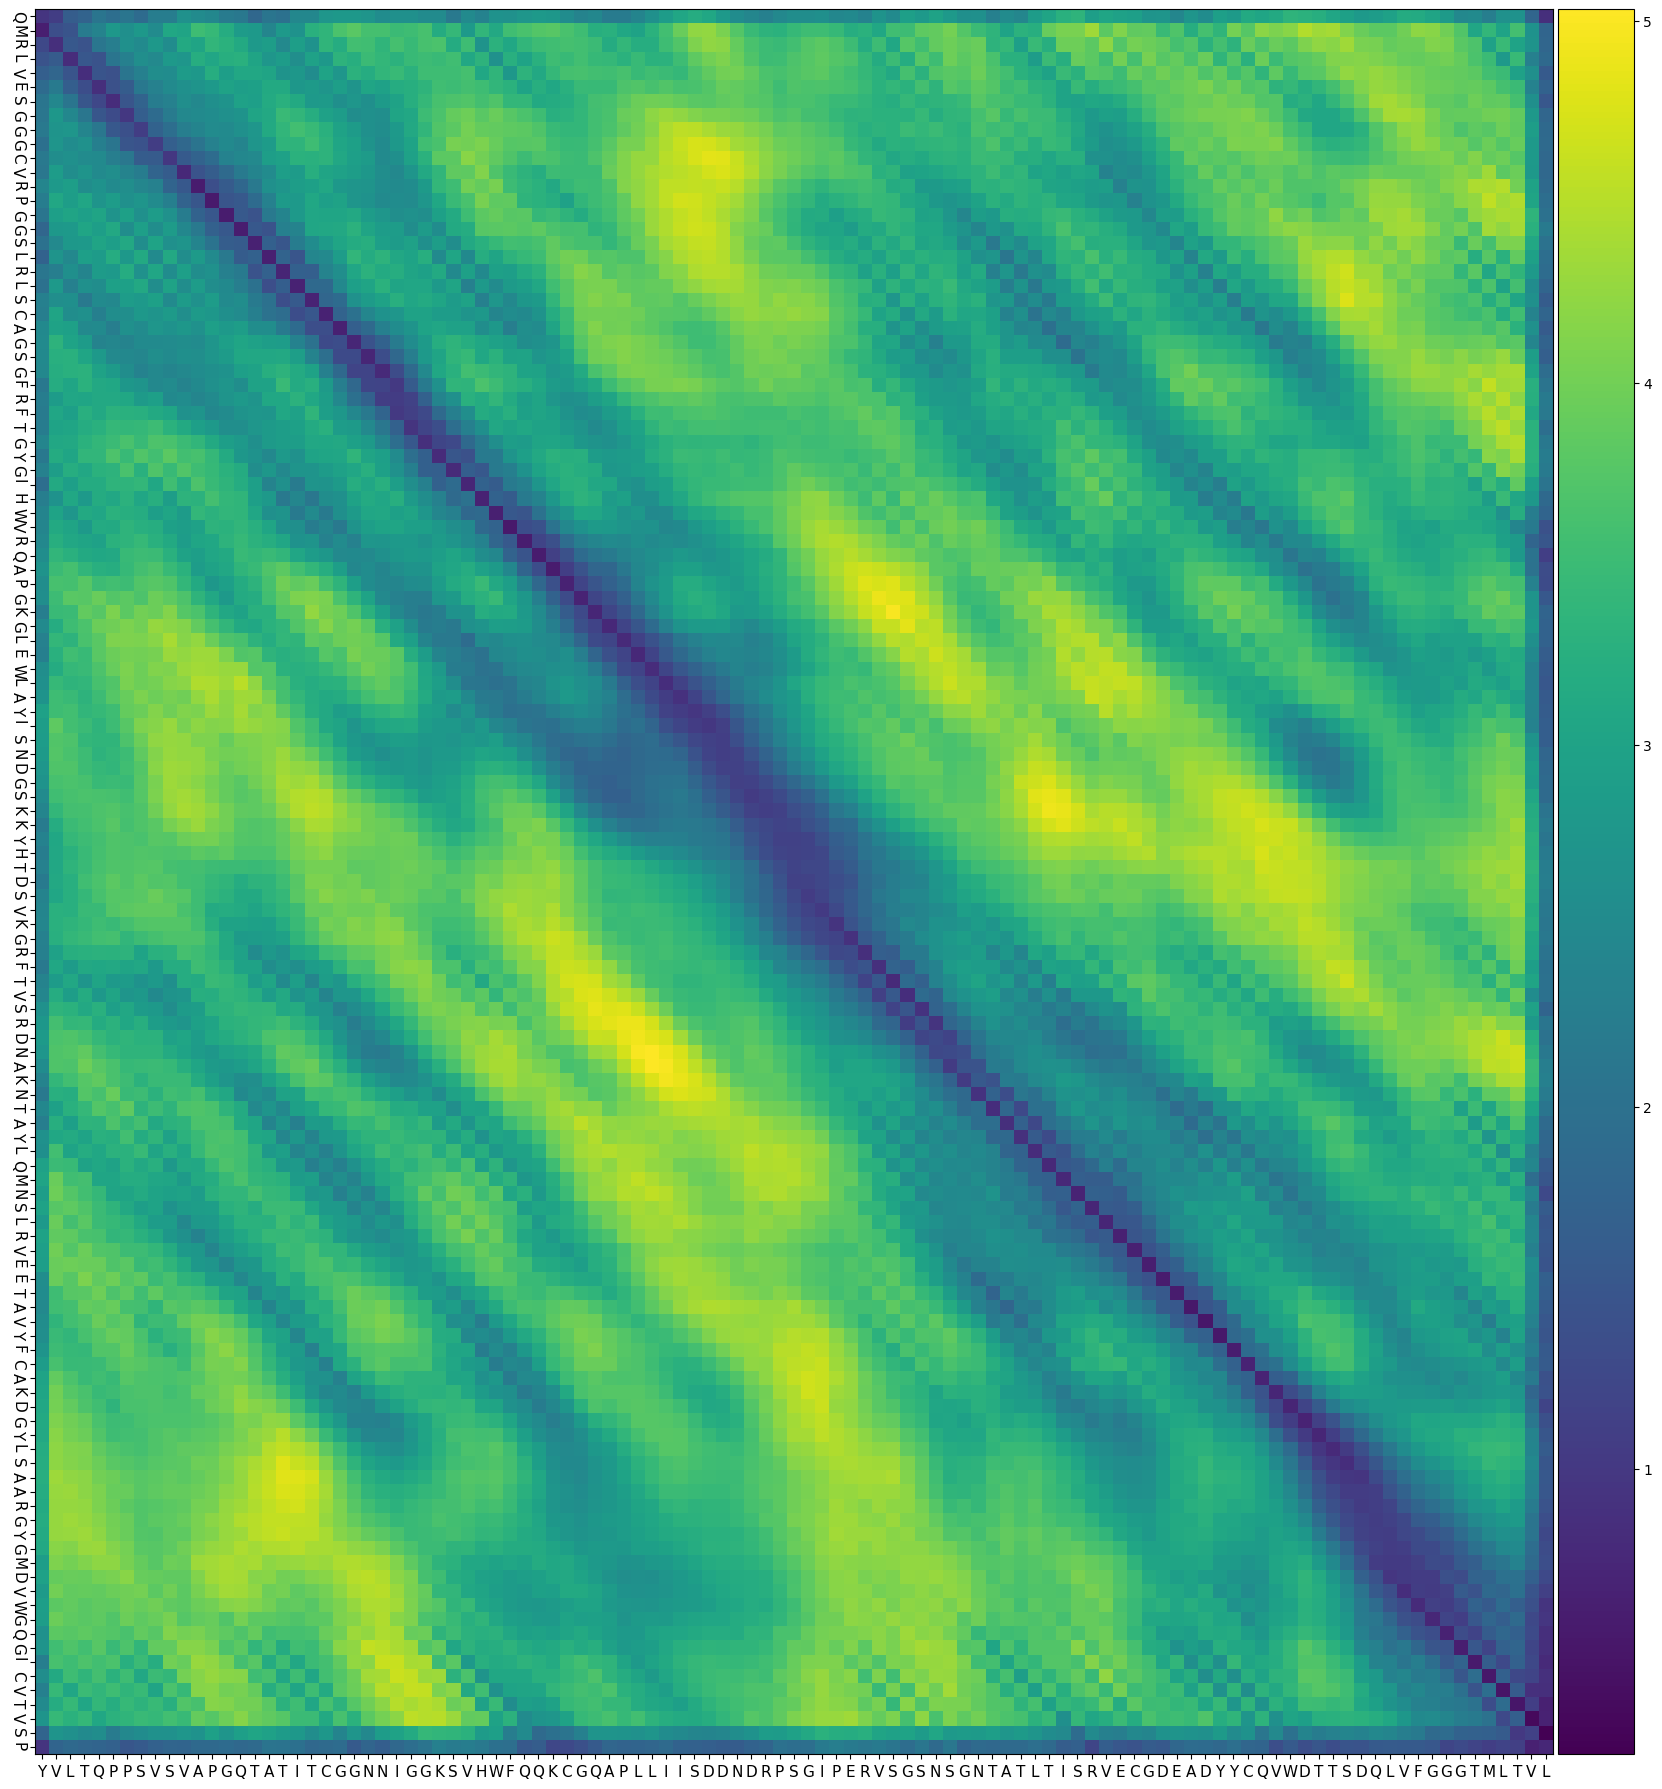

In [7]:
mat = res["cost_matrix"][0][mask_a.squeeze(0)][:, mask_b.squeeze(0)].cpu().numpy()
ker = np.eye(4)
img = convolve2d(mat, ker, padding_mode="same")

fig, ax = plt.subplots(1, 1, figsize=(24, 18))
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
im = ax.imshow(
    img,
    # cmap=mpl.colormaps["terrain"],
    # clim=(0, 1),
    interpolation="none",
)
fig.colorbar(im, cax=cax)

ax.set_xticks(range(len(seq2)), labels=list(seq2), fontsize=11)
ax.set_yticks(range(len(seq1)), labels=list(seq1), fontsize=11, rotation=270)

fig.tight_layout()
# fig.savefig("target.svg")
fig.show()